In [ ]:
# config.py
import torch
import os
import matplotlib.pyplot as plt
from PIL import Image

# --- Training Hyperparameters ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LEARNING_RATE_GEN = 1e-4
LEARNING_RATE_DISC = 1e-4
BATCH_SIZE = 16
NUM_EPOCHS_PRETRAIN = 50
NUM_EPOCHS_GAN = 100
HIGH_RES_SIZE = 96  # As per the paper
LOW_RES_SIZE = HIGH_RES_SIZE // 4
NUM_WORKERS = 4
LAMBDA_VGG = 1.0  # Weight for VGG/content loss
LAMBDA_ADV = 1e-3  # Weight for adversarial loss

os.makedirs("saved_models", exist_ok=True)

# --- Model Paths ---
PRETRAINED_GEN_PATH = "saved_models/srresnet_pretrained.pth"
GEN_PATH = "saved_models/generator.pth"
DISC_PATH = "saved_models/discriminator.pth"

# --- Dataset Paths ---
TRAIN_DIR = "/root/.cache/kagglehub/datasets/takihasan/div2k-dataset-for-super-resolution/versions/1/Dataset/DIV2K_train_HR"
TEST_DIR = "/root/.cache/kagglehub/datasets/takihasan/div2k-dataset-for-super-resolution/versions/1/Dataset/DIV2K_valid_HR"

# set the repo name
model_name = "keanteng/srgan-div2k-0723-v2"

In [ ]:
class VGGContentLoss(nn.Module):
    """
    Calculates the content loss in the VGG19 feature space.
    The paper uses the features from the layer before the 5th max-pooling layer (VGG54).
    In PyTorch's VGG19 implementation, this corresponds to `features[35]`.
    """
    def __init__(self, device):
        super(VGGContentLoss, self).__init__()
        vgg_model = vgg19(weights="DEFAULT").features[:36].to(device).eval()
        for param in vgg_model.parameters():
            param.requires_grad = False
        self.vgg_model = vgg_model
        self.loss = nn.MSELoss()

    def forward(self, generated, target):
        gen_features = self.vgg_model(generated)
        target_features = self.vgg_model(target)
        return self.loss(gen_features, target_features)

# From The Paper

```
to perceptually relevant characteristics. We formulate the
perceptual loss as the weighted sum of a content loss (lSR
X )
and an adversarial loss componen
```
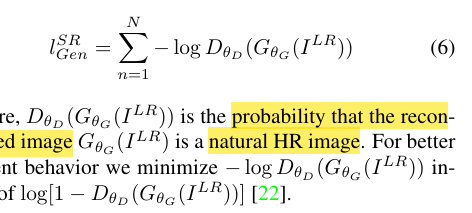

### Explanation

```python
self.adversarial_loss_fn = nn.BCEWithLogitsLoss()
adversarial_loss = self.adversarial_loss_fn(disc_fake_output, torch.ones_like(disc_fake_output))
```
- For SRGAN instead of minimizing log(1 - D(G(z))), the generator is trained to maximize log(D(G(z)))
- Maximizing log(D(G(z))) is equivalent to minimizing -log(D(G(z)))
- If D(G(z)) is close to 0 (bad generator), then log(D(G(z))) is a large negative number. Minimizing -log(D(G(z))) would then mean making this large negative number smaller (closer to zero), which provides a strong gradient signal for the generator to improve and make D(G(z)) closer to 1.

```
When the generator is poor (early in training), D(G(z)) will be close to 0 (discriminator easily identifies fakes).
If D(G(z)) is close to 0, then (1 - D(G(z))) is close to 1.
log(1 - D(G(z))) will then be close to log(1) = 0.
The gradient of log(1 - D(G(z))) with respect to the generator's parameters will be very small (saturated), meaning the generator receives little signal to learn and improve. This can hinder training.[4]
```

- How to get log from BCEWithLogitsLoss?
- The formula for BCEWithLogitsLoss(input, target) is roughly: `target * log(sigmoid(input)) - (1 - target) * log(1 - sigmoid(input))`

- Plugging these into the BCEWithLogitsLoss formula (and considering that target is 1):
    - Note that `torch.ones_like(disc_fake_output)` is the target, filled with ones
    - `Loss = -1 * log(sigmoid(disc_fake_output)) - (1 - 1) * log(1 - sigmoid(disc_fake_output))`
    - `Loss = -log(sigmoid(disc_fake_output))`

In [ ]:
from torch import nn

class PerceptualLoss(nn.Module):
    """
    Combined Perceptual Loss for SRGAN training.
    It includes VGG content loss and adversarial loss.
    """
    def __init__(self, device, lambda_vgg, lambda_adv):
        super(PerceptualLoss, self).__init__()
        self.vgg_loss_fn = VGGContentLoss(device) # load the function for vgg loss
        self.adversarial_loss_fn = nn.BCEWithLogitsLoss()
        self.lambda_vgg = lambda_vgg # is set to 1 based on the paper
        self.lambda_adv = lambda_adv # is set to 1e-3 based on the paper

    def forward(self, disc_fake_output, gen_hr, hr_img): # gen_hr is output fromm the generator
        # Content Loss
        vgg_loss = self.vgg_loss_fn(gen_hr, hr_img) # get both the generated image and high resolution image vgg or content loss

        # Adversarial Loss (Generator's perspective)
        # We want the generator to fool the discriminator, so we compare its output to a tensor of ones.
        adversarial_loss = self.adversarial_loss_fn(disc_fake_output, torch.ones_like(disc_fake_output)) # disc output is the output from the discriminator, we want to fool it into thinking that the generated image is real, so we compare it to a tensor of ones

        # Total Perceptual Loss
        total_loss = self.lambda_vgg * vgg_loss + self.lambda_adv * adversarial_loss # the formula from the paper
        return total_loss

In [1]:
import torch
torch.ones_like(torch.randn(1,3,2,2))

tensor([[[[1., 1.],
          [1., 1.]],

         [[1., 1.],
          [1., 1.]],

         [[1., 1.],
          [1., 1.]]]])